In [107]:
file='/kaggle/input/datasets/shashk99/offensive-data/processed_sold_dataset_v6_update_gpt.csv'


In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import ast

In [109]:
df = pd.read_csv(file)
df.drop(columns=['C14',	'C15',	'C16'	,'C17'	,'C18','C19'	,'C20',	'C21'	,'C22'	,'C23'	,'C24'	,'C25'	,'C26'	,'C27'	,'C28'], axis=1, inplace=True)
df.head()


,post_id,text,tokens,label,stereotype,category,text_length,off_word_count,rationales,offensive_words,target_type,target_group
0,995411387894542336,තේ නෙවෙයි තෝ බීලා ඉන්නෙ ගිනි වතුර,"['තේ', 'නෙවෙයි', 'තෝ', 'බීලා', 'ඉන්නෙ', 'ගිනි'...",OFF,0,['Gender'],33,1,"['0', '0', '1', '0', '0', '0', '0']",['තෝ'],UNT,NaN
1,1128238706303864832,@USER තුනක් ඕනේ නෑ එකක් ගැහුවනම් ඇති ලංකාවට ආප...,"['@USER', 'තුනක්', 'ඕනේ', 'නෑ', 'එකක්', 'ගැහුව...",OFF,0,['Gender'],74,1,"['0', '0', '1', '0', '0', '0', '0', '0', '0', ...",['ඕනේ'],UNT,NaN
2,1290554471714496514,"@USER , @USER @USER ටහුඩු ඒකි තනියම ජීවත් වෙ...","['@USER', ',', '@USER', '@USER', 'ටහුඩු', 'ඒකි...",OFF,0,['Gender'],76,4,"['0', '0', '0', '0', '1', '1', '0', '0', '1', ...","['ටහුඩු', 'ඒකි', 'වෙන්න', 'වෙන්න']",UNT,NaN
3,909459929446182913,@USER මර්විනුත් මුද්දරයක් වෙයිද දන්නේ නැ,"['@USER', 'මර්විනුත්', 'මුද්දරයක්', 'වෙයිද', '...",NOT,0,[],40,0,"['0', '0', '0', '0', '0', '0']",[],UNT,NaN
4,1305480579375198208,@USER ගොසිප් පීපල් නෙමේ හුත්තො. තෝ වගේ හොරෙක්ට...,"['@USER', 'ගොසිප්', 'පීපල්', 'නෙමේ', 'හුත්තො',...",OFF,0,['Gender'],83,3,"['0', '0', '0', '0', '1', '0', '1', '0', '1', ...","['හුත්තො', 'තෝ', 'හොරෙක්ට']",UNT,NaN


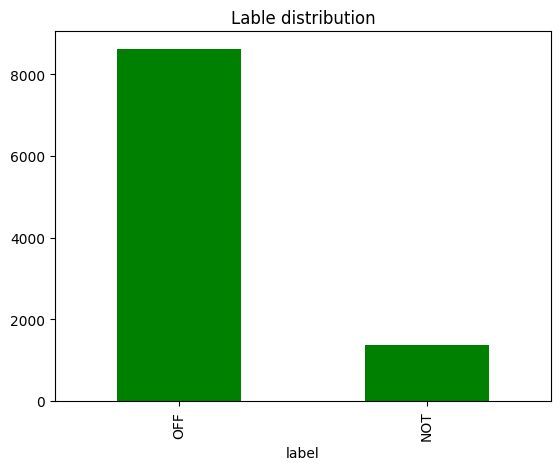

In [110]:
#offensive and non offesnive word count  and distribution

label_counts  =df['label'].value_counts()
label_counts.plot(kind='bar',color='green')

plt.title('Lable distribution')
plt.show()




In [111]:
#separate dataframe for offensive and non-offensive 
off= df['label']=='OFF'  
not_off= df['label']=='NOT' 
df_off=df[off].copy()
df_not_off=df[not_off].copy()
# df_off.head()



In [112]:
#offensive word count
off_words =df_off['offensive_words'].explode()
off_words.value_counts().head(20)

offensive_words
['පට්ට']      125
['යකෝ']       124
['තෝ']        119
['එක']         98
['පිස්සු']     92
['රෙද්ද']      83
['පලයන්']      74
['ටහුඩු']      71
['අයිසෙ']      68
['ඒකි']        66
['අඩො']        63
['කෑල්ල']      63
['කටට']        62
['හෙන']        61
['ගොනා']       58
['උඹ']         58
['මෝඩ']        58
['කැත']        57
['තඩි']        55
['පිස්සා']     55
Name: count, dtype: int64

In [113]:
df_off['off_word_count'].value_counts().sort_index()


off_word_count
1     3001
2     2315
3     1447
4      765
5      451
6      258
7      150
8       86
9       62
10      26
11      18
12       9
13      10
14       9
15       2
16       1
17       1
18       1
19       2
23       1
26       1
51       1
66       1
Name: count, dtype: int64

In [114]:
import warnings
import matplotlib

# Ignore the specific font warnings
warnings.filterwarnings("ignore", category=UserWarning, module="IPython.core.pylabtools")
warnings.filterwarnings("ignore", message="Glyph.*missing from font")

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
font_path = '/kaggle/working/NotoSansSinhala-Regular.ttf'


if os.path.exists(font_path):
    sinhala_font = fm.FontProperties(fname=font_path)
else:
    sinhala_font = None
    print("Font file not found. Please run: !apt-get install -y fonts-noto-core")



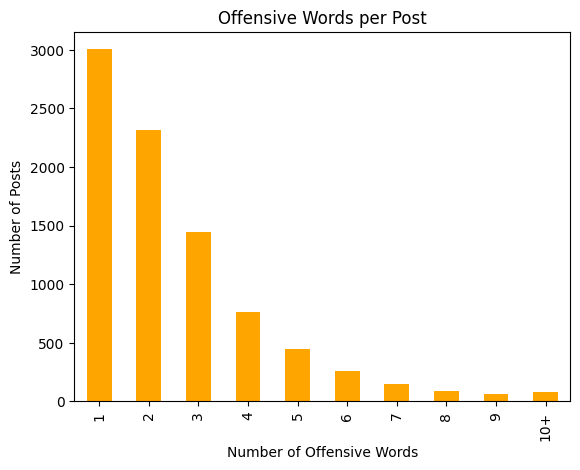

In [115]:
counts = df_off['off_word_count']

# group large values
counts_grouped = counts.apply(lambda x: x if x < 10 else 10)

table = counts_grouped.value_counts().sort_index()

# rename last category
table.index = [str(i) if i < 10 else "10+" for i in table.index]


table.plot(kind='bar', color='orange')

plt.title("Offensive Words per Post")
plt.xlabel("Number of Offensive Words")
plt.ylabel("Number of Posts")
plt.show()


In [116]:
off_words_cleaned = off_words.astype(str).str.strip("[]' ")

# 2. Now get the top 20
top_off_words = off_words_cleaned.value_counts().head(20)
print(top_off_words)

offensive_words
පට්ට      125
යකෝ       124
තෝ        119
එක         98
පිස්සු     92
රෙද්ද      83
පලයන්      74
ටහුඩු      71
අයිසෙ      68
ඒකි        66
අඩො        63
කෑල්ල      63
කටට        62
හෙන        61
ගොනා       58
උඹ         58
මෝඩ        58
කැත        57
තඩි        55
පිස්සා     55
Name: count, dtype: int64


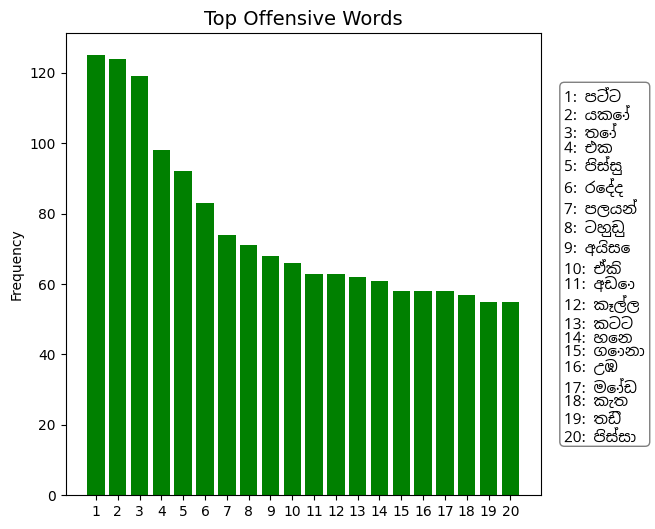

In [117]:

labels = [str(x) for x in top_off_words.index]
counts = top_off_words.values
x_indexes = range(len(labels))

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x_indexes, counts, color='green' )

ax.set_xticks(x_indexes)
ax.set_xticklabels([i+1 for i in x_indexes])

plt.title("Top Offensive Words", fontsize=14, )
plt.ylabel("Frequency")

label_text = "\n".join([f"{i+1}: {label}" for i, label in enumerate(labels)])

plt.text(1.05, 0.5, label_text, 
         transform=ax.transAxes, 
         fontsize=11, 
         verticalalignment='center', 
         fontproperties=sinhala_font,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.subplots_adjust(right=0.6) 
plt.show()